In [19]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
np.random.seed(42)
torch.manual_seed(42)

In [20]:
import numpy as np
X_train = np.load('../step1/X_train.npy')
X_val = np.load('../step1/X_val.npy')
X_test = np.load('../step1/X_test.npy')
y_train = np.load('../step1/y_train.npy')
y_val = np.load('../step1/y_val.npy')
y_test = np.load('../step1/y_test.npy')

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (2099, 13), Val: (450, 13), Test: (451, 13)


In [33]:
class RBFLayer(nn.Module):

    # φ(x) = exp(-||x-c||² / (2σ²))

    def __init__(self, num_inputs, num_centers, centers=None, sigma=1.0,
                 trainable_centers=False, trainable_sigma=False):


        super().__init__()
        self.num_centers = num_centers
        self.num_inputs = num_inputs

        #  مقداردهی مراکز
        if centers is None:
            # اگر مرکزی ندادیم، با اعداد تصادفی کوچک مقداردهی می‌کنیم
            centers = np.random.randn(num_centers, num_inputs) * 0.1

        # تبدیل به تنسور پایتورچ و مشخص می‌کنیم که قابل آموزش باشد یا نه
        self.centers = nn.Parameter(
            torch.tensor(centers, dtype=torch.float32),
            requires_grad=trainable_centers  # اگر True باشه، در حین آموزش تغییر می‌کنه
        )

        # مقداردهی شعاع‌ها
        if isinstance(sigma, (float, int)):
            # اگر sigma یک عدد بود، برای همه مراکز یکسان می‌کنیم
            sigma = np.full((num_centers,), sigma)

        self.sigma = nn.Parameter(
            torch.tensor(sigma, dtype=torch.float32),
            requires_grad=trainable_sigma  # اگر True باشه، شعاع‌ها هم تغییر می‌کنن
        )

    def forward(self, x):
        diff = x.unsqueeze(1) - self.centers.unsqueeze(0)


        distances_sq = torch.sum(diff ** 2, dim=2)  # (batch, centers)


        out = torch.exp(-distances_sq / (2 * self.sigma.unsqueeze(0) ** 2))

        return out

print(" لایه RBF ساخته شد")

 لایه RBF ساخته شد


In [34]:
class RBFNetwork(nn.Module):
    def __init__(self, num_inputs, num_centers, num_classes=3,
                 centers=None, sigma=1.0,
                 trainable_centers=False, trainable_sigma=False):

        super().__init__()

        # لایه اول: لایه RBF (توابع پایه شعاعی)
        self.rbf = RBFLayer(
            num_inputs, num_centers, centers, sigma,
            trainable_centers, trainable_sigma
        )

        # لایه دوم: لایه خروجی خطی (از k تا 3 کلاس)
        self.output_layer = nn.Linear(num_centers, num_classes)

    def forward(self, x):
        h = self.rbf(x)  # خروجی: (batch, k)

        # عبور از لایه خروجی
        logits = self.output_layer(h)

        return logits

print(" شبکه RBF ساخته شد")

 شبکه RBF ساخته شد


In [35]:
import time
from torch.utils.data import DataLoader, TensorDataset

def initialize_centers_kmeans(X_train, num_centers):
    kmeans = KMeans(n_clusters=num_centers, random_state=42, n_init=10)
    kmeans.fit(X_train)
    return kmeans.cluster_centers_

def initialize_centers_random(X_train, num_centers):
    indices = np.random.choice(len(X_train), num_centers, replace=False)
    return X_train[indices]

def train_rbf(model, X_train, y_train, X_val, y_val, epochs=150, lr=0.01,
              batch_size=32, patience=15, verbose=True):
    """
    آموزش مدل RBF با:
    - Mini-Batch Training (batch_size)
    - Early Stopping (patience)
    """
    start_time = time.time()

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # ایجاد DataLoader برای Mini-Batch
    train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                                   torch.tensor(y_train, dtype=torch.long))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.long)

    history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
    best_val_f1 = 0
    best_state = None
    epochs_no_improve = 0  # برای Early Stopping

    for epoch in range(epochs):
        # آموزش با Mini-Batch
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(train_loader)

        #  ارزیابی روی اعتبارسنجی
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_t)
            val_loss = criterion(val_outputs, y_val_t)
            val_pred = torch.argmax(val_outputs, dim=1).numpy()
            val_f1 = f1_score(y_val, val_pred, average='macro')

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss.item())
        history['val_f1'].append(val_f1)

        #  Early Stopping
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_train_loss:.4f} | Val Loss: {val_loss.item():.4f} | Val F1: {val_f1:.4f}")

        # شرط توقف Early Stopping
        if epochs_no_improve >= patience:
            if verbose:
                print(f" Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
            break

    model.load_state_dict(best_state)
    training_time = time.time() - start_time  #  زمان آموزش
    return history, best_val_f1, training_time

print(" توابع کمکی (با Batch، Early Stopping، Time) تعریف شدند")

 توابع کمکی (با Batch، Early Stopping، Time) تعریف شدند


In [28]:
print("=" * 80)
print("آزمایش 1: تعداد مراکز مختلف و روش‌های مختلف مقداردهی")
print("=" * 80)

results = []
centers_options = [50, 100, 200, 300]
init_methods = [
    ('k-means', 'k-means clustering'),
    ('random_from_data', 'random from training data'),
    ('random_normal', 'random normal (mean=0, std=0.1)')
]

for num_centers in centers_options:
    for init_key, init_desc in init_methods:
        print(f"\n--- آزمایش: {num_centers} مرکز - روش مقداردهی: {init_desc} ---")

        if init_key == 'k-means':
            centers = initialize_centers_kmeans(X_train, num_centers)
        elif init_key == 'random_from_data':
            centers = initialize_centers_random(X_train, num_centers)
        else:
            centers = np.random.randn(num_centers, X_train.shape[1]) * 0.1

        model = RBFNetwork(
            num_inputs=X_train.shape[1],
            num_centers=num_centers,
            num_classes=3,
            centers=centers,
            sigma=1.0,
            trainable_centers=False,
            trainable_sigma=False
        )

        # استفاده از تابع جدید با batch_size و early stopping
        history, val_f1, training_time = train_rbf(
            model, X_train, y_train, X_val, y_val,
            epochs=150, lr=0.01, batch_size=32, patience=15, verbose=True
        )

        results.append({
            'تعداد_مراکز': num_centers,
            'روش_مقداردهی': init_desc,
            'batch_size': 32,
            'early_stop': 'patience=15',
            'آموزش_مراکز': 'ثابت',
            'آموزش_شعاع': 'ثابت',
            'F1_اعتبارسنجی': val_f1,
            'زمان_آموزش(ثانیه)': training_time
        })
        print(f" F1: {val_f1:.4f} | زمان: {training_time:.2f} ثانیه")


# ========== آزمایش 2: trainable vs fixed centers ==========
print("\n" + "=" * 80)
print("آزمایش 2: trainable centers (مراکز قابل آموزش) vs fixed centers (مراکز ثابت)")
print("=" * 80)

best_num_centers = 300  # از نتایج قبلی

for trainable_centers in [False, True]:
    desc = "قابل آموزش" if trainable_centers else "ثابت"
    print(f"\n--- آزمایش: مراکز {desc} (تعداد مراکز = {best_num_centers}) ---")

    centers = initialize_centers_kmeans(X_train, best_num_centers)

    model = RBFNetwork(
        num_inputs=X_train.shape[1],
        num_centers=best_num_centers,
        num_classes=3,
        centers=centers,
        sigma=1.0,
        trainable_centers=trainable_centers,
        trainable_sigma=False
    )

    history, val_f1, training_time = train_rbf(
        model, X_train, y_train, X_val, y_val,
        epochs=150, lr=0.01, batch_size=32, patience=15, verbose=True
    )

    results.append({
        'تعداد_مراکز': best_num_centers,
        'روش_مقداردهی': 'k-means',
        'batch_size': 32,
        'early_stop': 'patience=15',
        'آموزش_مراکز': desc,
        'آموزش_شعاع': 'ثابت',
        'F1_اعتبارسنجی': val_f1,
        'زمان_آموزش(ثانیه)': training_time
    })
    print(f" F1 برای مراکز {desc}: {val_f1:.4f} | زمان: {training_time:.2f} ثانیه")


# ========== آزمایش 3: Trainable Sigma ==========
print("\n" + "=" * 80)
print("آزمایش 3: Trainable Sigma (شعاع قابل آموزش) vs Fixed Sigma")
print("=" * 80)

for trainable_sigma in [False, True]:
    desc = "قابل آموزش" if trainable_sigma else "ثابت"
    print(f"\n--- آزمایش: شعاع {desc} (تعداد مراکز = {best_num_centers}) ---")

    centers = initialize_centers_kmeans(X_train, best_num_centers)

    model = RBFNetwork(
        num_inputs=X_train.shape[1],
        num_centers=best_num_centers,
        num_classes=3,
        centers=centers,
        sigma=1.0,
        trainable_centers=False,
        trainable_sigma=trainable_sigma
    )

    history, val_f1, training_time = train_rbf(
        model, X_train, y_train, X_val, y_val,
        epochs=150, lr=0.01, batch_size=32, patience=15, verbose=True
    )

    results.append({
        'تعداد_مراکز': best_num_centers,
        'روش_مقداردهی': 'k-means',
        'batch_size': 32,
        'early_stop': 'patience=15',
        'آموزش_مراکز': 'ثابت',
        'آموزش_شعاع': desc,
        'F1_اعتبارسنجی': val_f1,
        'زمان_آموزش(ثانیه)': training_time
    })
    print(f" F1 برای شعاع {desc}: {val_f1:.4f} | زمان: {training_time:.2f} ثانیه")


# ========== آزمایش 4: محاسبه Sigma از فاصله مراکز ==========
print("\n" + "=" * 80)
print("آزمایش 4: محاسبه Sigma از فاصله مراکز")
print("=" * 80)

from sklearn.metrics import pairwise_distances

centers = initialize_centers_kmeans(X_train, best_num_centers)
# محاسبه میانگین فاصله هر مرکز تا نزدیک‌ترین مرکز دیگر
distances = pairwise_distances(centers)
np.fill_diagonal(distances, np.inf)
min_distances = np.min(distances, axis=1)
sigma_from_dist = np.mean(min_distances)
print(f"محاسبه شده: sigma = {sigma_from_dist:.4f}")

model = RBFNetwork(
    num_inputs=X_train.shape[1],
    num_centers=best_num_centers,
    num_classes=3,
    centers=centers,
    sigma=sigma_from_dist,
    trainable_centers=False,
    trainable_sigma=False
)

history, val_f1, training_time = train_rbf(
    model, X_train, y_train, X_val, y_val,
    epochs=150, lr=0.01, batch_size=32, patience=15, verbose=True
)

results.append({
    'تعداد_مراکز': best_num_centers,
    'روش_مقداردهی': 'k-means',
    'batch_size': 32,
    'early_stop': 'patience=15',
    'آموزش_مراکز': 'ثابت',
    'آموزش_شعاع': f'از فاصله مراکز ({sigma_from_dist:.3f})',
    'F1_اعتبارسنجی': val_f1,
    'زمان_آموزش(ثانیه)': training_time
})
print(f" F1 با sigma از فاصله مراکز: {val_f1:.4f} | زمان: {training_time:.2f} ثانیه")


# نمایش جدول کامل نتایج
print("\n" + "=" * 80)
print("جدول کامل نتایج آزمایش‌ها (طبق مستند پروژه):")
print("=" * 80)
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# پیدا کردن بهترین مدل
best_row = df_results.loc[df_results['F1_اعتبارسنجی'].idxmax()]
best_num_centers = int(best_row['تعداد_مراکز'])
print(f"\n بهترین تعداد مراکز: {best_num_centers}")
print(f" بهترین F1 اعتبارسنجی: {best_row['F1_اعتبارسنجی']:.4f}")

آزمایش 1: تعداد مراکز مختلف و روش‌های مختلف مقداردهی

--- آزمایش: 50 مرکز - روش مقداردهی: k-means clustering ---
Epoch 20/150 | Loss: 0.6401 | Val Loss: 0.6517 | Val F1: 0.7291
⏹️ Early stopping at epoch 24 (no improvement for 15 epochs)
✅ F1: 0.7392 | زمان: 7.49 ثانیه

--- آزمایش: 50 مرکز - روش مقداردهی: random from training data ---
Epoch 20/150 | Loss: 0.7209 | Val Loss: 0.7414 | Val F1: 0.6687
Epoch 40/150 | Loss: 0.6754 | Val Loss: 0.7022 | Val F1: 0.6809
⏹️ Early stopping at epoch 49 (no improvement for 15 epochs)
✅ F1: 0.6848 | زمان: 10.40 ثانیه

--- آزمایش: 50 مرکز - روش مقداردهی: random normal (mean=0, std=0.1) ---
Epoch 20/150 | Loss: 0.8971 | Val Loss: 0.9084 | Val F1: 0.4953
Epoch 40/150 | Loss: 0.8711 | Val Loss: 0.8821 | Val F1: 0.4887
Epoch 60/150 | Loss: 0.8551 | Val Loss: 0.8673 | Val F1: 0.5711
Epoch 80/150 | Loss: 0.8434 | Val Loss: 0.8544 | Val F1: 0.5812
Epoch 100/150 | Loss: 0.8349 | Val Loss: 0.8457 | Val F1: 0.5968
Epoch 120/150 | Loss: 0.8265 | Val Loss: 0.8429

In [29]:
from sklearn.metrics import classification_report, precision_recall_fscore_support

print("=" * 70)
print("بهترین مدل - ارزیابی کامل روی تست")
print("=" * 70)

best_num_centers = int(best_row['تعداد_مراکز'])
print(f"بهترین تعداد مراکز: {best_num_centers}")
print(f"F1 اعتبارسنجی آن: {best_row['F1_اعتبارسنجی']:.4f}")

# آموزش مدل نهایی با بهترین پارامترها
centers = initialize_centers_kmeans(X_train, best_num_centers)
final_model = RBFNetwork(
    num_inputs=X_train.shape[1],
    num_centers=best_num_centers,
    num_classes=3,
    centers=centers,
    sigma=1.0,
    trainable_centers=False,
    trainable_sigma=False
)

# آموزش با زمان
start_test = time.time()
history, best_val_f1, training_time = train_rbf(
    final_model, X_train, y_train, X_val, y_val,
    epochs=200, lr=0.01, batch_size=32, patience=15, verbose=True
)
training_time = time.time() - start_test

# ارزیابی روی تست
final_model.eval()
X_test_t = torch.tensor(X_test, dtype=torch.float32)

with torch.no_grad():
    test_outputs = final_model(X_test_t)
    test_pred = torch.argmax(test_outputs, dim=1).numpy()

# ========== گزارش کامل معیارها ==========
test_acc = accuracy_score(y_test, test_pred)
test_macro_f1 = f1_score(y_test, test_pred, average='macro')
test_weighted_f1 = f1_score(y_test, test_pred, average='weighted')

# Precision, Recall, F1 برای هر کلاس
precision, recall, f1_per_class, _ = precision_recall_fscore_support(y_test, test_pred, average=None)
per_class_f1 = f1_score(y_test, test_pred, average=None)

# گزارش کامل
print("\n نتایج نهایی روی داده‌های تست:")
print(f" دقت (Accuracy): {test_acc:.4f}")
print(f" F1 میانگین (Macro-F1): {test_macro_f1:.4f}")
print(f" F1 وزنی (Weighted-F1): {test_weighted_f1:.4f}")
print(f" زمان آموزش مدل نهایی: {training_time:.2f} ثانیه")

print("\n گزارش دقیق هر کلاس (Precision, Recall, F1):")
print("کلاس | Precision | Recall | F1-score")
print("-----|-----------|--------|---------")
class_names = ['Good', 'Acceptable', 'Poor']
for i, name in enumerate(class_names):
    print(f"{name:6} | {precision[i]:.4f}    | {recall[i]:.4f}  | {f1_per_class[i]:.4f}")

print("\n خلاصه با classification_report:")
print(classification_report(y_test, test_pred, target_names=class_names))

# ماتریس درهم‌ریختگی
cm = confusion_matrix(y_test, test_pred)
print("\nماتریس درهم‌ریختگی:")
print(cm)

بهترین مدل - ارزیابی کامل روی تست
بهترین تعداد مراکز: 300
F1 اعتبارسنجی آن: 0.8521
Epoch 20/200 | Loss: 0.3979 | Val Loss: 0.4799 | Val F1: 0.8051
Epoch 40/200 | Loss: 0.3403 | Val Loss: 0.4530 | Val F1: 0.8057
⏹️ Early stopping at epoch 43 (no improvement for 15 epochs)

📊 نتایج نهایی روی داده‌های تست:
✅ دقت (Accuracy): 0.7783
✅ F1 میانگین (Macro-F1): 0.7683
✅ F1 وزنی (Weighted-F1): 0.7745
✅ زمان آموزش مدل نهایی: 12.89 ثانیه

📋 گزارش دقیق هر کلاس (Precision, Recall, F1):
کلاس | Precision | Recall | F1-score
-----|-----------|--------|---------
Good   | 0.8272    | 0.5929  | 0.6907
Acceptable | 0.7510    | 0.8407  | 0.7933
Poor   | 0.8034    | 0.8393  | 0.8210

📋 خلاصه با classification_report:
              precision    recall  f1-score   support

        Good       0.83      0.59      0.69       113
  Acceptable       0.75      0.84      0.79       226
        Poor       0.80      0.84      0.82       112

    accuracy                           0.78       451
   macro avg       0.79 

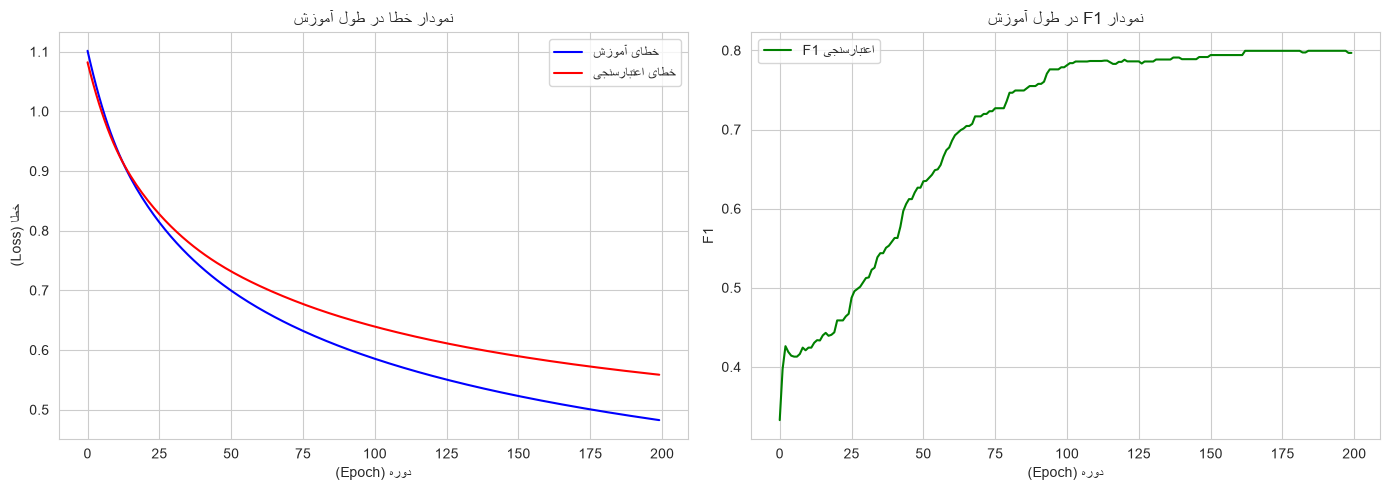

✅ نمودارها ذخیره شدند


In [12]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ----- نمودار سمت چپ: Loss -----
axes[0].plot(history['train_loss'], label='خطای آموزش', color='blue')
axes[0].plot(history['val_loss'], label='خطای اعتبارسنجی', color='red')
axes[0].set_xlabel('دوره (Epoch)')
axes[0].set_ylabel('خطا (Loss)')
axes[0].set_title('نمودار خطا در طول آموزش')
axes[0].legend()
axes[0].grid(True)

# ----- نمودار سمت راست: F1 -----
axes[1].plot(history['val_f1'], label='F1 اعتبارسنجی', color='green')
axes[1].set_xlabel('دوره (Epoch)')
axes[1].set_ylabel('F1')
axes[1].set_title('نمودار F1 در طول آموزش')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('rbf_training_curves.png', dpi=150)  # ذخیره تصویر
plt.show()
print(" نمودارها ذخیره شدند")

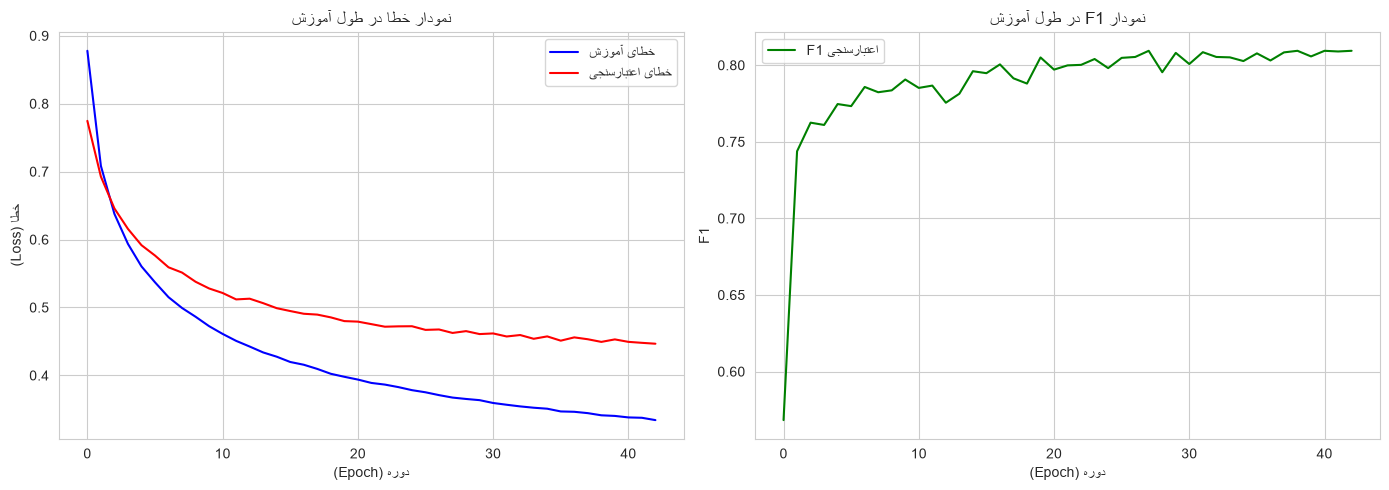

✅ نمودارها ذخیره شدند


In [30]:
#  رسم نمودارهای Loss و F1

# ایجاد دو نمودار کنار هم
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ----- نمودار سمت چپ: Loss -----
axes[0].plot(history['train_loss'], label='خطای آموزش', color='blue')
axes[0].plot(history['val_loss'], label='خطای اعتبارسنجی', color='red')
axes[0].set_xlabel('دوره (Epoch)')
axes[0].set_ylabel('خطا (Loss)')
axes[0].set_title('نمودار خطا در طول آموزش')
axes[0].legend()
axes[0].grid(True)

# ----- نمودار سمت راست: F1 -----
axes[1].plot(history['val_f1'], label='F1 اعتبارسنجی', color='green')
axes[1].set_xlabel('دوره (Epoch)')
axes[1].set_ylabel('F1')
axes[1].set_title('نمودار F1 در طول آموزش')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('rbf_training_curves.png', dpi=150)  # ذخیره تصویر
plt.show()
print("✅ نمودارها ذخیره شدند")

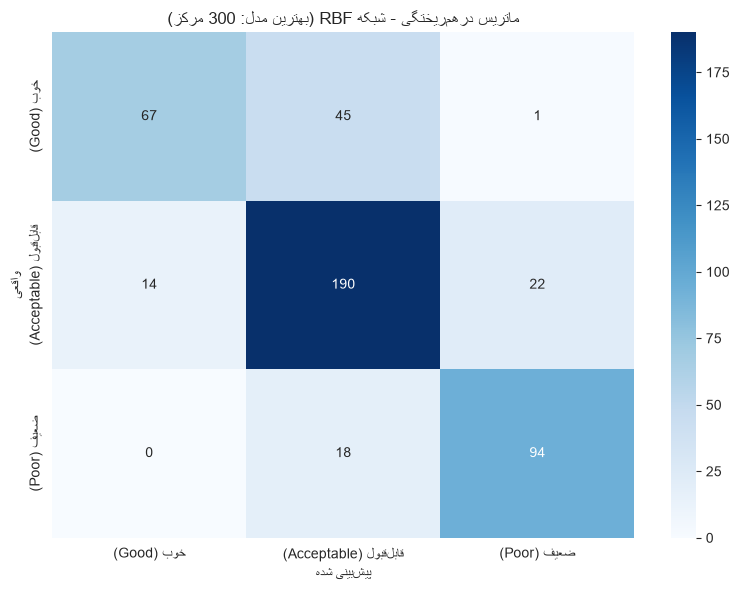

✅ ماتریس درهم‌ریختگی ذخیره شد


In [31]:
#  رسم ماتریس درهم‌ریختگی (Confusion Matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['خوب (Good)', 'قابل‌قبول (Acceptable)', 'ضعیف (Poor)'],
            yticklabels=['خوب (Good)', 'قابل‌قبول (Acceptable)', 'ضعیف (Poor)'])
plt.xlabel('پیش‌بینی شده')
plt.ylabel('واقعی')
plt.title(f'ماتریس درهم‌ریختگی - شبکه RBF (بهترین مدل: {best_num_centers} مرکز)')
plt.tight_layout()
plt.savefig('rbf_confusion_matrix.png', dpi=150)
plt.show()
print(" ماتریس درهم‌ریختگی ذخیره شد")

In [38]:
# سلول 10: ذخیره مدل و خلاصه نهایی
torch.save(final_model.state_dict(), 'best_rbf_model.pth')
print(" مدل نهایی ذخیره شد: best_rbf_model.pth")

print(f" بهترین تعداد مراکز: {best_num_centers}")
print(f" Batch Size: 32")
print(f" Early Stopping: patience=15")
print(f" F1 اعتبارسنجی: {best_row['F1_اعتبارسنجی']:.4f}")
print(f" زمان آموزش (Validation): {best_row['زمان_آموزش(ثانیه)']:.2f} ثانیه")
print(f" دقت روی تست: {test_acc:.4f}")
print(f" F1 میانگین روی تست: {test_macro_f1:.4f}")
print(f" F1 وزنی روی تست: {test_weighted_f1:.4f}")
print("\n نکته: در این آزمایش‌ها موارد زیر بررسی شد:")
print("   - Batch Size = 32")
print("   - Early Stopping (patience=15)")
print("   - Trainable Centers (ثابت vs قابل آموزش)")
print("   - Trainable Sigma (ثابت vs قابل آموزش)")
print("   - Sigma محاسبه شده از فاصله مراکز")

 مدل نهایی ذخیره شد: best_rbf_model.pth
 بهترین تعداد مراکز: 300
 Batch Size: 32
 Early Stopping: patience=15
 F1 اعتبارسنجی: 0.8521
 زمان آموزش (Validation): 12.17 ثانیه
 دقت روی تست: 0.7783
 F1 میانگین روی تست: 0.7683
 F1 وزنی روی تست: 0.7745

 نکته: در این آزمایش‌ها موارد زیر بررسی شد:
   - Batch Size = 32
   - Early Stopping (patience=15)
   - Trainable Centers (ثابت vs قابل آموزش)
   - Trainable Sigma (ثابت vs قابل آموزش)
   - Sigma محاسبه شده از فاصله مراکز
